In [2]:
#2. Import library pandas dan generate data dummy menggunakan DataFrame. Kemudian tampilkan data tersebut.

import pandas as pd

data = {'luas': [6, 8, 10, 14, 18],
        'harga': [7, 9, 13, 17.5, 18]}

df = pd.DataFrame(data)
df

,luas,harga
0,6,7.0
1,8,9.0
2,10,13.0
3,14,17.5
4,18,18.0


Matplotlib is building the font cache; this may take a moment.


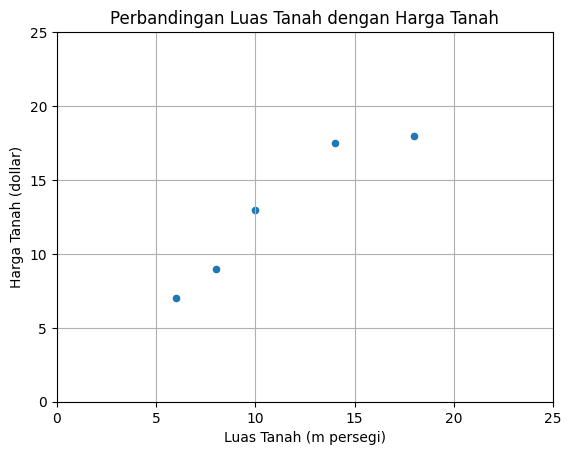

In [ ]:
#3. Visualisasikan data tersebut melalui scatterplot dengan menggunakan library matplotlib.

import matplotlib.pyplot as plt

df.plot(kind='scatter', x='luas', y='harga')
plt.title('Perbandingan Luas Tanah dengan Harga Tanah')
plt.xlabel('Luas Tanah (m persegi)')
plt.ylabel('Harga Tanah (dollar)')
plt.xlim(0, 25)
plt.ylim(0, 25)
plt.grid(True)
plt.show()

In [1]:
#4. Pisahkan variabel dependen dengan variabel independent

import numpy as np

X = np.array([6,8,10,14,18]).reshape(-1,1)
y = np.array([7,9,13,17.5,18])

In [ ]:
#5. Latih model regresi linear yang akan digunakan untuk memprediksi harga rumah. Kemudian tampilkan nilai intercept dan slope variablenya 

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print(f'Intersept: {model.intercept_}')
print(f'slope: {model.coef_}')

Intersept: 1.965517241379315
slope: [0.9762931]


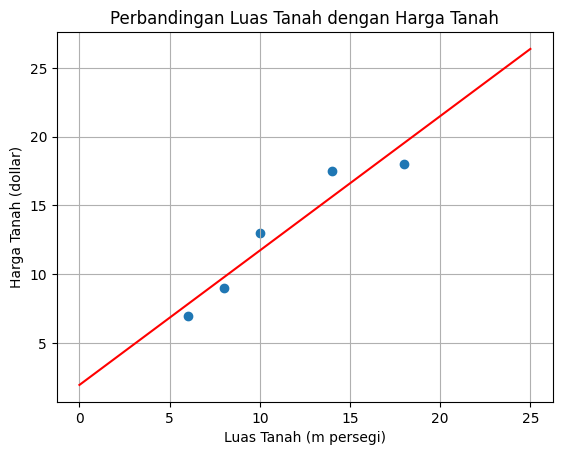

In [ ]:
# 6. Visualisasikan garis persamaan linear yang dihasilkan setelah pelatihan model. 
X_vis = np.array([0,25]).reshape(-1,1)
y_vis = model.predict(X_vis)

plt.scatter(X, y)
plt.plot(X_vis, y_vis, color='red')

plt.title('Perbandingan Luas Tanah dengan Harga Tanah')
plt.xlabel('Luas Tanah (m persegi)')
plt.ylabel('Harga Tanah (dollar)')
# plt.xlim(0, 25)
# plt.ylim(0, 25)
plt.grid(True)
plt.show()

In [49]:
#7. Lakukan prediksi harga rumah untuk luas tanah 12 m2, 15 m2, dan 20 m2

luas_tanah = np.array([12,15,20]).reshape(-1,1)
luas_tanah

harga_prediksi = model.predict(luas_tanah)
harga_prediksi

array([13.68103448, 16.60991379, 21.49137931])

In [9]:
#8. Tampilkan hasil prediksi harga rumah

for luas, hrg in zip(luas_tanah, harga_prediksi):
    print(f'Luas Tanah {luas}: harga prediksi: {hrg}')

NameError: name 'luas_tanah' is not defined

In [50]:
# LATIHAN 2:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
df = pd.DataFrame(data=housing.data, columns=housing.feature_names)

df['MedHouseValue'] = pd.Series(housing.target)

target = df['MedHouseValue']          # Dependent Variable
inputs = df.drop(['MedHouseValue'], axis=1)  # Independent Variable

df.tail()   # menampilkan 5 data terakhir

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [51]:
targets = df['MedHouseValue']          # variabel yang diprediksi
inputs = df.drop(['MedHouseValue'], axis=1)  # semua fitur selain target

# 3. Bagi dataset menjadi data latih (70%) dan data uji (30%)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    inputs, targets, test_size=0.3, random_state=1
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(14448, 8) (6192, 8)
(14448,) (6192,)


In [40]:
# 4. Latih model regresi linear
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print(f'intercept: {lr_model.intercept_}')
print(f'slope: {lr_model.coef_}')

intercept: -37.285328998751616
slope: [ 4.41037995e-01  9.68801816e-03 -1.04781309e-01  6.22052706e-01
 -5.61452681e-06 -3.28792384e-03 -4.23182318e-01 -4.37898856e-01]


MSE: 0.5296293151408239
R2: 0.5971429737359626


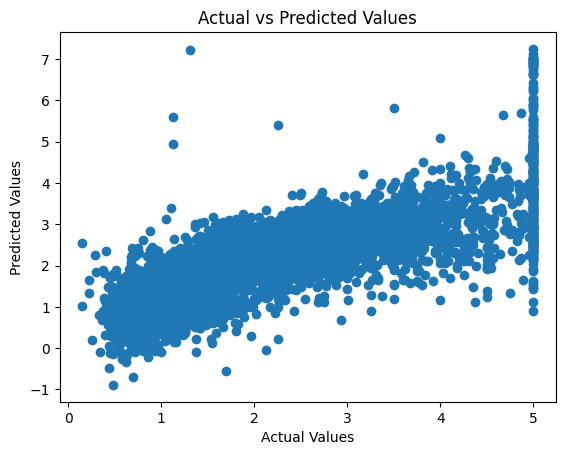

In [44]:
#5. Evaluasi model (MSE dan R²)
from sklearn.metrics import mean_squared_error

y_pred = lr_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = lr_model.score(X_test, y_test)

print(f'MSE: {mse}')
print(f'R2: {r2}')

import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

In [45]:
# 6. Simpan model yang telah dilatih
import pickle

filename = 'finalized_model.sav'
pickle.dump(lr_model, open(filename, 'wb'))

In [ ]:
# Lakukan evaluasi model pada latihan 2 dengan menggunakan RMSE dan MAE
# Kode menghitung MAE dan RMSE
# Tambahkan setelah bagian prediksi y_pred.

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.5352476763196592
RMSE: 0.7277563569910083
